## Simulador — Bubble

Notebook para simulação interativa do projeto Bubble.

- Temos um grafo $G$ com $\text{num\_nodes}$ vértices, onde cada vértice possui $|\text{words\_per\_node}|$ palavras de interesse.

> **Nota:** Toda a lógica foi movida para o pacote `bubble` (em `src/bubble/`).
> Este notebook apenas **importa e usa** os módulos do pacote.

In [1]:
from bubble import BubbleModel, DEFAULT_CONFIG, create_model
from bubble.affinity import cosine_similarity, dot_product
from bubble.selection import select_by_max_degree, select_randomly
from bubble.messages import opposite_uniform_message, opposite_unique_message
from bubble.metrics import cross_group_connectivity, modularity_value, assortativity_value
from bubble.scaling import constant_scaling, linear_scaling, log_scaling, power_law_scaling, sqrt_scaling

### Simulação

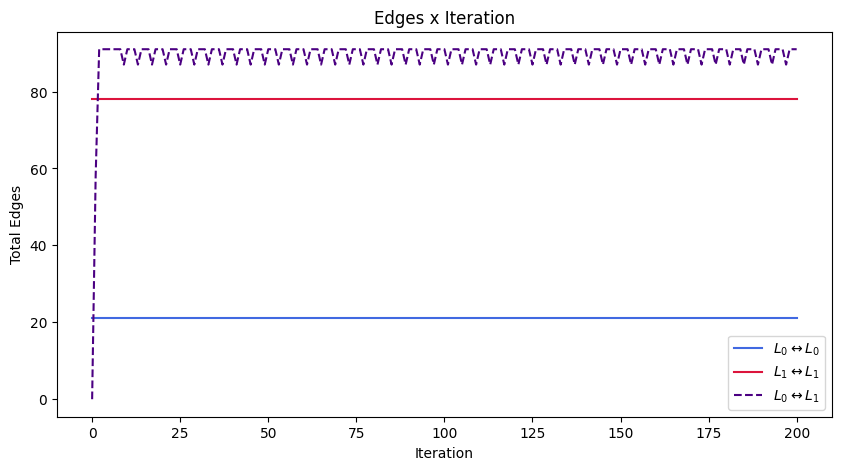

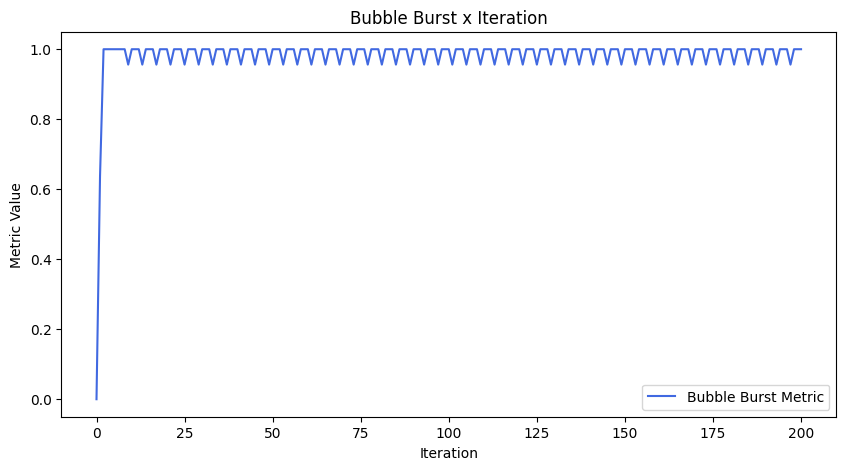

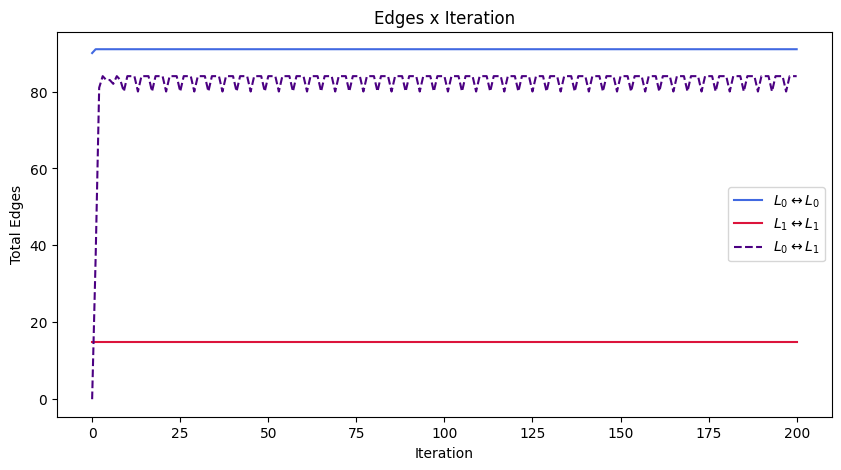

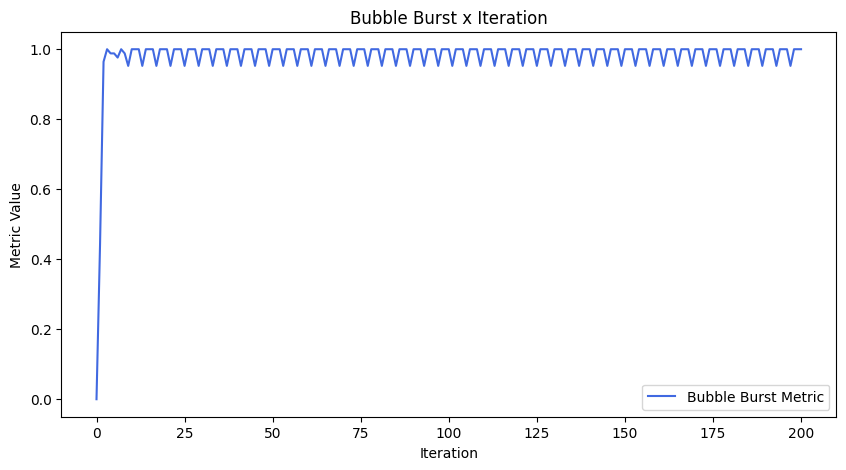

In [2]:
# --- Configuration --------------------------------------------------------
# Use defaults or customize via create_model({"num_nodes": 50, ...})
config = DEFAULT_CONFIG

# --- Run with uniform messages -------------------------------------------
g = BubbleModel(config)
wpn = g.words_per_node
g.run(200, opposite_uniform_message(wpn, 0), opposite_uniform_message(wpn, 1))

# --- Run with unique messages --------------------------------------------
G = BubbleModel(config)
G.run(200, opposite_unique_message(wpn, 0), opposite_unique_message(wpn, 1))

# --- Plot ----------------------------------------------------------------
g.plot_edge_counts()
g.plot_bubble_burst()
G.plot_edge_counts()
G.plot_bubble_burst()

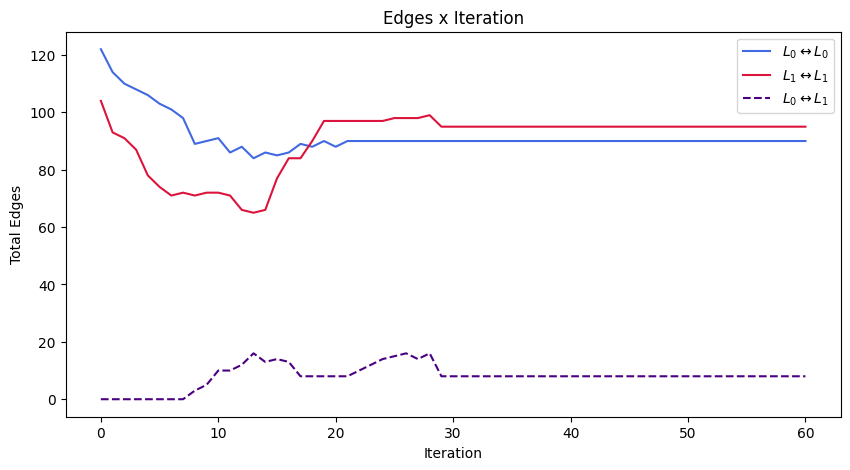

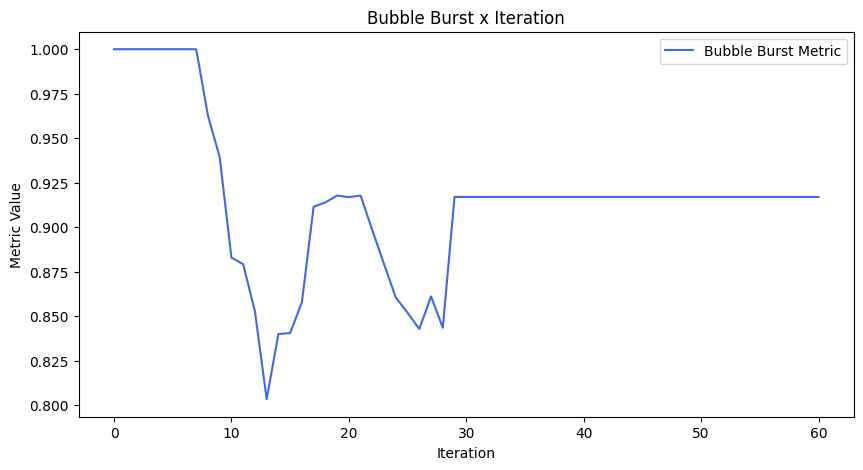

In [3]:
# Run with custom configuration
custom_config = create_model({
    "num_nodes": 100,
    "words_per_node": (5,5),
    "beta" : 0.3,
    "gamma" : 0.1,
    "affinity_level": 0.9,
    "influencer_scaling": constant_scaling(5),
    "influencer_selection": select_by_max_degree,
    "bubble_burst_metric_name": 'assortativity_value'
})

g = BubbleModel(custom_config)
wpn = g.words_per_node
g.run(60, opposite_uniform_message(wpn, 0), opposite_uniform_message(wpn, 1))
g.plot_edge_counts()
g.plot_bubble_burst()